## Phase 3 — Machine Learning: Predicting Underserved Films

### Objective
Phase 2 identified systematic underexposure bias at the **genre level**.
Phase 3 extends this analysis to the **individual film level**, using binary 
classification to predict whether a film is underserved by the platform's 
recommendation system.

### How "Underserved" is Defined
For each individual film:
1. Calculate `avg_rating` and `rating_count` from the ratings data
2. Normalize both using percentile rank → `rating_pct`, `exposure_pct`
3. `bias_score = rating_pct − exposure_pct`
4. `is_underserved = 1 if bias_score > 0 else 0`

A film is considered underserved if its quality ranking exceeds its 
exposure ranking — it deserves more visibility than it receives.

### Features
| Feature | Source | Rationale |
|---------|--------|-----------|
| `avg_rating` | ratings | Measures film quality |
| `genre_count` | movies | Number of genres a film belongs to; more genres = more recommendation surface |
| `is_[genre]` | movies | Binary dummies for each genre; captures genre composition |

Note: `rating_count` is intentionally excluded (see Conceptual Notes below).

### Models
- **Logistic Regression** — Primary model; interpretable coefficients allow 
  business-level explanation of each feature's impact
- **Random Forest** — Secondary model; used for accuracy comparison and 
  feature importance ranking

### Connection to Phase 2
Phase 2 showed a moderate negative correlation (r = −0.365) between genre 
quality and exposure at the aggregate level. Phase 3 tests whether this 
pattern holds at the film level, and whether genre composition alone can 
predict systematic underexposure.

## Conceptual Notes — For Reference

### 1. Why `rating_count` Cannot Be a Feature (Data Leakage / Endogeneity)

The target variable `is_underserved` is derived from `bias_score`:

    bias_score = rating_pct − exposure_pct
    exposure_pct = f(rating_count)

Therefore:

    rating_count → exposure_pct → bias_score → is_underserved (target)

Using `rating_count` as a feature means using the answer to predict the 
answer — the model would be cheating, not learning.

This is equivalent to **endogeneity** in econometrics: when an explanatory 
variable is correlated with the outcome by construction, not by a true 
causal relationship.

`avg_rating` does not have this problem. Although it influences `rating_pct`, 
the target variable is the *gap* between rating and exposure — the model 
still needs to learn whether the exposure is justified given the rating. 
`avg_rating` alone cannot tell you that.

### 2. Linear Regression vs. Logistic Regression

| | Linear Regression | Logistic Regression |
|---|---|---|
| Output | Any numerical value (unbounded) | Probability between 0 and 1 |
| Use case | Predicting continuous values | Predicting binary outcomes |
| Formula | y = β₀ + β₁x₁ + β₂x₂ + ... | P(y=1) = 1 / (1 + e^−(β₀ + β₁x₁ + ...)) |
| Both are | Linear models | Linear models |

The key mechanism in Logistic Regression is the **sigmoid function** 
`1 / (1 + e^−z)`, which compresses any input into the 0–1 range, 
making the output interpretable as a probability.

Why not use Linear Regression for binary outcomes? Because it can produce 
values outside [0, 1] (e.g. −0.3 or 1.7), which have no probabilistic meaning.

### 3. Exposure Proxy Limitation (Carried Over from Phase 2)
`rating_count` is used as a proxy for platform exposure. It may also reflect 
organic audience size, historical content volume, and user search behavior — 
not just algorithmic recommendation. This limitation applies to both Phase 2 
and Phase 3 findings.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

movies = pd.read_csv('../data/raw/ml-latest-small/movies.csv')
ratings = pd.read_csv('../data/raw/ml-latest-small/ratings.csv')

In [23]:
merged = pd.merge(movies, ratings, on='movieId', how='inner')

# --- Step 2: Film-level aggregation ---
# Calculate avg_rating and rating_count for each individual film
film_stats = ratings.groupby('movieId').agg( # here use rating for avg_rating and rating_count calculation cause its lighter, compared to merged's dataset
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

# --- Step 3: Merge film_stats back with movies to get genres ---
film_df = pd.merge(film_stats, movies[['movieId', 'genres']], 
                   on='movieId', how='inner')

# --- Step 4: Remove films with no genres listed ---
film_df = film_df[film_df['genres'] != '(no genres listed)']


# Quick check
print(film_df.shape)
print(film_df.head())


(76718, 4)
   movieId  avg_rating  rating_count  \
0        1    3.893508         76813   
1        2    3.278179         30209   
2        3    3.171271         15820   
3        4    2.868395          3028   
4        5    3.076957         15801   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [24]:
# --- Step 5: Normalize avg_rating and rating_count to percentile rank ---
film_df['rating_pct'] = film_df['avg_rating'].rank(pct=True)
film_df['exposure_pct'] = film_df['rating_count'].rank(pct=True)

# --- Step 6: Calculate bias_score and target variable ---
film_df['bias_score'] = film_df['rating_pct'] - film_df['exposure_pct']
film_df['is_underserved'] = (film_df['bias_score'] > 0).astype(int)

# Check the distribution of target variable
print(film_df['is_underserved'].value_counts())
print(film_df['is_underserved'].value_counts(normalize=True))

is_underserved
0    45117
1    31601
Name: count, dtype: int64
is_underserved
0    0.588089
1    0.411911
Name: proportion, dtype: float64


In [25]:
# Normalize avg_rating and rating_count to percentile rank
film_df['rating_pct'] = film_df['avg_rating'].rank(pct=True)
film_df['exposure_pct'] = film_df['rating_count'].rank(pct=True)

film_df['bias_score'] = film_df['rating_pct'] - film_df['exposure_pct']
film_df['is_underserved'] = (film_df['bias_score'] > 0).astype(int) # film_df['bias_score] > 0 returns boolean (T/F) but ML needs figures so astype(int) changes T/F into 1/0

print(film_df['is_underserved'].value_counts()) # number
print(film_df['is_underserved'].value_counts(normalize=True)) # ration

is_underserved
0    45117
1    31601
Name: count, dtype: int64
is_underserved
0    0.588089
1    0.411911
Name: proportion, dtype: float64


59% vs 41% of not underserved and underserved shows that they are balanced classes. 

In [26]:
# Genre Features

# 先排除 imax 因為他不是一個真正的 genre 再算 genre_count 不然 imax 會被算進去
film_df = film_df[~film_df['genres'].str.contains('IMAX')]

# genre_count: how many genres each film belongs to
film_df['genre_count'] = film_df['genres'].apply( # apply: 對每行做一樣的事; x = 每一行的 genre 值 e.g. Comedy|Romance
    lambda x: len(x.split('|')) # x.split('|') 把每個 x 用 ｜ 切開變成 list > ["Comedy", "Romance"]; len(x.split('|')) = 2 即可計算出每部電影有幾個 genres
)

# is_[genre]: binary dummy for each genre
# str.get_dummies('|')專門用來處理「一格裡有多個值用符號分隔」的欄位。它會用 | 切割每一行，然後自動為每個唯一值建立一個 binary 欄位
genre_dummies = film_df['genres'].str.get_dummies('|') 

# Combine them back to film_df
film_df = pd.concat([film_df, genre_dummies], axis=1) # axis=1 橫向合併（欄位）； axis=0 縱向合併（上下黏在一起）

print(f"Total features created: {genre_dummies.shape[1]} genre dummies")
print(f"film_df shape: {film_df.shape}")
print(film_df[['movieId', 'genres', 'genre_count'] +
              list(genre_dummies.columns[:5])].head()) # 取前五個確認格式即可


Total features created: 18 genre dummies
film_df shape: (76523, 27)
   movieId                                       genres  genre_count  Action  \
0        1  Adventure|Animation|Children|Comedy|Fantasy            5       0   
1        2                   Adventure|Children|Fantasy            3       0   
2        3                               Comedy|Romance            2       0   
3        4                         Comedy|Drama|Romance            3       0   
4        5                                       Comedy            1       0   

   Adventure  Animation  Children  Comedy  
0          1          1         1       1  
1          1          0         1       0  
2          0          0         0       1  
3          0          0         0       1  
4          0          0         0       1  


pd.concat只要執行一次就會貼一次，所以如果上面這個 cell 跑超過一遍 dummies 的數量就會不對

In [27]:
print(film_df.groupby('is_underserved')['genre_count'].mean())

is_underserved
0    1.958674
1    1.644169
Name: genre_count, dtype: float64


In [28]:
# Define features (x) and target varoable (y)

# 創建一個 variable 可以一次呼叫所有 dummy genres 才不用X = film_df[['avg_rating', 'genre_count', 'Action', 'Adventure', 'Animation', ...]]
# 先用 pandas 套件 .columns 把 genre_dummies 的 index 全叫出來→ Index(['Action', 'Adventure', 'Animation', ...])
# 再把他們轉成 list (因為要把 genre dummines 跟 avg_rating, genre_count 合併起來，index 不能黏 list)
genre_cols = list(genre_dummies.columns)

# Intentionally excluding rating_count (data leakage = endogenity)
X = film_df[['avg_rating', 'genre_count'] + genre_cols]

# Target variable y
y = film_df['is_underserved']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures used: {list(X.columns)}")


X shape: (76523, 20)
y shape: (76523,)

Features used: ['avg_rating', 'genre_count', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


## Train/Test: 80/20
## Overfitting
Definition:  high training accuracy (say 99%) but low test accuracy (65%), it happens when:
1. **Too few data and model is too complicated**: say there are only 100 data but 1000 variables
2. **Train for too long**: model has more chance to "memorize" the answers
3. **Too many features but too few data**: 20 features + 50 data, model tends to find fake patterns
4. **Model too complex**: if one doesn't trim decision tree, it'll keep splitting until each training data is perfectly categorized — this kind of tree has no use for new data

`sklearn`（scikit-learn）是一個很大的 ML 套件，裡面有很多功能。為了組織這些功能，它把不同用途的工具分裝在不同的**子模組_submodule**裡。
```
sklearn
├── model_selection  → 負責資料切割、交叉驗證
├── linear_model     → 負責線性模型（包括 Logistic Regression）
├── ensemble         → 負責組合模型（包括 Random Forest）
├── metrics          → 負責評估模型表現
├── preprocessing    → 負責資料前處理
└── ...
```

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set size: {X_train.shape} film")
print(f"Test set size: {X_test.shape} films")

Training set size: (61218, 20) film
Test set size: (15305, 20) films


## Logistic Regression
- Logistic regression 透過反覆調整參數找到最佳預測結果（像是調收音機那樣，不停嘗試直到調到正確的頻道）
- 每「調整一次」就是一次 iteration（迭代）：找一條最佳的數學公式。每次迭代都在微調公式裡的參數（β值），讓預測錯誤越來越小，直到收斂。
```
目標：找到最佳的 β0, β1, β2...
迭代 1：β = [0.1, 0.3, -0.2...] → 錯誤率 35%
迭代 2：β = [0.2, 0.4, -0.1...] → 錯誤率 28%
迭代 3：β = [0.25, 0.38, -0.15...] → 錯誤率 24%
...
迭代 847：β = [0.31, 0.42, -0.18...] → 錯誤率 24%（不再改善）→ 停止
```
- 預設只迭代 100 次，如果迭代 100 次還沒有找到最佳參數，會停下來報錯（ConvergenceWarning: maximum iterations reached）
- in this case 有 20 個 features、9532 筆，比較複雜，100 次可能不夠。設 max_iter=1000 給它足夠的機會收斂（找到最佳參數
- 收斂：每次迭代的改善幅度小到可以忽略，代表已經找到最佳解，不需要再調整了。

## Sklearn 邏輯
建立 model（空的，還沒學任何東西的 linear model/logistic regression）>>
.fit()（把 training data 餵給 model，讓它學習）>>
.predict()（用學到的知識對新資料做預測）

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

print("====Logistic Regression====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}") #（四捨五入到小數點後3位）
print(classification_report(y_test, y_pred_lr))

====Logistic Regression====
Accuracy: 0.749
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      9038
           1       0.70      0.67      0.69      6267

    accuracy                           0.75     15305
   macro avg       0.74      0.74      0.74     15305
weighted avg       0.75      0.75      0.75     15305



## Model Evaluation Metrics

### The 4 Prediction Outcomes
|  | 真實是 1 (underserved) | 真實是 0 (overpromoted) |
|---|---|---|
| **預測是 1** | True Positive (TP) ✓ | False Positive (FP) ✗ |
| **預測是 0** | False Negative (FN) ✗ | True Negative (TN) ✓ |

---

### Accuracy
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

所有預測裡，預測正確的比例。
**限制：** 當兩個 class 樣本數量差距很大時，accuracy 會有誤導性。
例如：95% 是 class 0，model 全部預測 0，accuracy = 95% 但其實什麼都沒學到。

---

### Precision（精確率）
$$Precision = \frac{TP}{TP + FP}$$

「我說是 1 的，有多少真的是 1？」
**專注在 FP（誤報）的代價。**

**什麼時候優先看 Precision：**
誤報的代價很高。例如：
- 垃圾郵件過濾（把正常郵件誤標成垃圾郵件代價高）
- 法院判決（把無辜的人判有罪代價高）

---

### Recall（召回率）
$$Recall = \frac{TP}{TP + FN}$$

「真正是 1 的，我找到了幾個？」
**專注在 FN（漏報）的代價。**

**什麼時候優先看 Recall：**
漏報的代價很高。例如：
- 癌症篩檢（漏掉真正有癌症的人代價高）
- 詐欺偵測（漏掉真正的詐欺案代價高）

---

### F1-score
$$F1 = \frac{2 \times Precision \times Recall}{Precision + Recall}$$

Precision 和 Recall 的調和平均數。

**什麼時候優先看 F1：**
當你同時在意 Precision 和 Recall，不想犧牲任何一個。
例如：資訊檢索、兩個 class 都同樣重要的分類問題。

**為什麼用調和平均而不是普通平均：**
調和平均對極端值更敏感。
Precision = 1.0, Recall = 0.0 →
- 普通平均 = 0.50（看起來還行）
- 調和平均 = 0.00（正確反映 model 完全沒用）

---

### Macro avg vs Weighted avg

| | 計算方式 | 什麼時候看 |
|---|---|---|
| **Macro avg** | 每個 class 直接平均，不管樣本數 | 兩個 class 同樣重要，即使樣本數不同 |
| **Weighted avg** | 按樣本數加權平均 | 樣本數差距大，想反映整體表現 |

**你的專案：** 兩個 class 樣本數接近（1048 vs 859），
macro avg 和 weighted avg 結果幾乎一樣（都是 0.76），
所以看哪個都可以。

---

### 本專案應該看哪個指標？

專案目標是**找出被系統低估的電影**推薦給平台改善。

- 漏掉真正 underserved 的電影（FN）→ 平台繼續忽略這些電影，問題沒被解決
- 誤報不是 underserved 的電影（FP）→ 平台多關注了一些其實還好的電影，代價較低

**結論：Recall 比 Precision 更重要。**
漏報的代價遠高於誤報，所以你更在意 model 能找到多少真正被低估的電影。
Class 1 Recall = 0.73，代表真正 underserved 的電影裡，
model 找到了 73%，漏掉了 27%。

#### 判斷要看哪個指標的 Tips #####
```
你更怕哪種錯誤？
        ↓
怕「誤報」（冤枉好人）→ 看 Precision
        ↓
怕「漏報」（放走壞人）→ 看 Recall
        ↓
兩個都怕，不想取捨 → 看 F1
        ↓
想看整體表現 → 看 Accuracy
（前提：兩個 class 樣本數差不多）
```

In [32]:
# Check average genre_count and most common genres for each class
print("=== Average genre_count by class ===")
print(film_df.groupby('is_underserved')['genre_count'].mean())

print("\n=== Most common genres in Class 0 (overpromoted) ===")
class0 = film_df[film_df['is_underserved'] == 0]
print(class0[genre_cols].sum().sort_values(ascending=False).head(5))

print("\n=== Most common genres in Class 1 (underserved) ===")
class1 = film_df[film_df['is_underserved'] == 1]
print(class1[genre_cols].sum().sort_values(ascending=False).head(5))

=== Average genre_count by class ===
is_underserved
0    1.958674
1    1.644169
Name: genre_count, dtype: float64

=== Most common genres in Class 0 (overpromoted) ===
Drama       18621
Comedy      13810
Thriller     8314
Horror       6682
Action       6502
dtype: int64

=== Most common genres in Class 1 (underserved) ===
Drama          13951
Comedy          8293
Documentary     6148
Romance         3943
Thriller        3063
dtype: int64


### Logistic Regression 結果
Class 0 (overpromoted) outperforms Class 1 (underserved).
(Recall: 0.67 vs 0.80). Initial hypothesis that mainstream genre patterns 
were more recognizable was not supported by data — top genres appear 
similarly across both classes. The more likely explanation is the 
difference in support size (1048 vs 859).

## Random Forest 

### What is a Decision Tree

Random Forest 是由很多棵 Decision Tree 組成的，先理解單棵 Decision Tree。比起Logistic Regression, Random Forest 沒有迭代：它不是在調參數，而是在建結構。每棵 tree 獨立建立，建完就固定了，不會回頭修改。

Decision Tree 用一連串 if-else 問題來分類，每個分支點叫做一個 **node**：

```
avg_rating > 3.5?
├── Yes → genre_count < 2?
│         ├── Yes → is_underserved = 1 （高評分 + 少 genre → 可能是冷門好片）
│         └── No  → is_underserved = 0
└── No  → is_underserved = 0 （評分低 → 大概不是被低估）
```

**問題：** 如果不加限制，Decision Tree 會一直分裂直到把每一筆
training data 完美分類——它把答案背起來了，遇到新資料就失準。
這就是 **overfitting**。

---

### How Random Forest Solves Overfitting

Random Forest 的核心思想：**建立很多棵不同的 Decision Tree，讓它們針對每部電影投票是否為underserved (in this case)。**

```
Training data (7625 部電影)
        ↓
建立 100 棵 Decision Tree
每棵 tree 看不同的資料子集 + 不同的 features
        ↓
對一部新電影預測：
  Tree 1   → 1 (underserved)
  Tree 2   → 0 (overpromoted)
  Tree 3   → 1 (underserved)
  ...
  Tree 100 → 1 (underserved)
        ↓
投票結果：67 棵說 0，33 棵說 1 → 最終預測該部電影（e.g. Toy Story) = 0 (is NOT underserved)
```

單棵 tree 可能出錯，但 100 棵 tree 一起投票，錯誤會互相抵消。每棵 tree 投一票，票數比例就是機率，機率過門檻就是最終預測。

---

### Two Randomness Mechanisms

**Mechanism 1 — Bootstrap Sampling（資料隨機抽樣）**

每棵 tree 不是看全部 7625 筆 training data，而是隨機抽取一部分
（有放回，意思是同一筆資料可能被抽到多次）。

```
原始資料：電影 A, B, C, D, E, F, G ...（7625 部）

Tree 1 看到：A, A, C, E, E, G, H ...（隨機抽樣，A 被抽到兩次）
Tree 2 看到：B, C, C, D, F, F, I ...（不同的隨機抽樣）
Tree 3 看到：A, B, D, D, E, G, G ...（又不同）
```

每棵 tree 的訓練資料略有不同 → 每棵 tree 學到略有不同的規律。

**Mechanism 2 — Feature Randomness（特徵隨機選取）**

每個 node 分裂時，不是從全部 20 個 features 裡找最佳分割點，
而是隨機選出一部分 features，只從這幾個裡面挑。

```
Tree 1, Node 1：從 [avg_rating, Comedy, Drama, genre_count, Action] 裡挑
Tree 1, Node 2：從 [War, Romance, avg_rating, Horror, genre_count] 裡挑
Tree 2, Node 1：從 [Film-Noir, Comedy, Thriller, Drama, avg_rating] 裡挑
```

這確保不同的 tree 不會每次都依賴同樣的 features，
避免所有 tree 都長得一樣。

---

### Feature Importance

Random Forest 訓練完之後會自動計算每個 feature 的重要性：
這個 feature 被用來分裂 node 的次數越多、分裂效果越好，重要性越高。

重要性數值加總等於 1，例如：
```
avg_rating     0.35   ← 最重要，幾乎每棵 tree 都用它來分裂
genre_count    0.18
Drama          0.08
Comedy         0.07
...
```

這告訴你：哪些特徵真正影響一部電影是否被系統低估。

---

### Decision Tree vs Random Forest

|  | Decision Tree | Random Forest |
|---|---|---|
| Overfitting 風險 | 高（容易背答案） | 低（100棵投票互相抵消錯誤） |
| 準確度 | 中 | 高 |
| 可解釋性 | 高（可以畫出來） | 中（100棵無法逐一解釋） |
| 訓練速度 | 快 | 較慢（要建 100 棵） |

---

### Parameters Used

- `n_estimators=100` — 建立 100 棵 Decision Tree
- `random_state=42` — 固定隨機種子，確保結果可重現
- `feature_importances_` — 訓練完之後自動產生的屬性，回傳每個 feature 的重要性分數
- `pd.Series(data, index=)` — 把 array 轉成 pandas Series 並加上欄位名稱，方便排序和閱讀

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Feed the model with training data, make it learn
rf_model.fit(X_train, y_train)

# Use the learned model to predict on test set
y_pred_rf = rf_model.predict(X_test)

# Show result
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

# Show feature importance
feature_importance = pd.Series( #把 feature_importances_ 這個 array 轉成 pandas Series
    rf_model.feature_importances_,
    index=X.columns # 並用 X.columns當作 index，這樣每個重要性數字都對應到正確的 feature 名稱，方便排序和閱讀。
).sort_values(ascending=False)

print("\n=== Feature Importance (Top 10) ===")
print(feature_importance.head(10))


Accuracy: 0.861
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      9038
           1       0.80      0.88      0.84      6267

    accuracy                           0.86     15305
   macro avg       0.85      0.86      0.86     15305
weighted avg       0.86      0.86      0.86     15305


=== Feature Importance (Top 10) ===
avg_rating     0.875966
genre_count    0.023276
Documentary    0.020693
Horror         0.010331
Thriller       0.007942
Drama          0.006942
Comedy         0.005594
Sci-Fi         0.005423
Action         0.005372
Adventure      0.004501
dtype: float64


## Phase 3 Results & Key Findings

### Model Comparison

| Model | Accuracy | Class 1 Recall | Class 1 F1 |
|-------|----------|----------------|------------|
| Logistic Regression | 0.749 | 0.67 | 0.69 |
| **Random Forest** | **0.861** | **0.88** | **0.84** |

Random Forest outperforms Logistic Regression by 11.2% in accuracy,
and improves Class 1 (underserved) Recall from 0.67 to 0.88 —
meaning it successfully identifies 88% of truly underserved films.

Since our goal is to minimise missed underserved films (false negatives),
Recall is the primary metric. Random Forest is the stronger model for
this use case.

---

### Feature Importance (Random Forest)

| Feature | Importance |
|---------|------------|
| avg_rating | 0.876 |
| genre_count | 0.023 |
| Documentary | 0.021 |
| Horror | 0.010 |
| Thriller | 0.008 |
| ... | ... |

`avg_rating` alone accounts for **88% of predictive power**.
All genre-related features combined account for only ~12%.

---

### Key Finding: avg_rating Dominance

`avg_rating` dominates because of its structural relationship with
the target variable:

    bias_score = rating_pct − exposure_pct
    rating_pct = f(avg_rating)
    is_underserved = 1 if bias_score > 0

A high `avg_rating` directly raises `rating_pct`, which raises
`bias_score`, which raises the probability of `is_underserved = 1`.
The model is not cheating (this is not data leakage — `rating_count`
was correctly excluded), but the structural link is strong enough
that `avg_rating` dominates the signal.

**Why we keep avg_rating anyway:**
Removing it would not be justified — it is a legitimate predictor
with real business meaning. Its dominance is itself a finding:
the strongest signal of underexposure is film quality, not genre.
Platforms systematically underserve high-quality films, regardless
of genre composition.

---

### Key Finding: Genre Has Limited Predictive Power at Film Level

The hypothesis that niche genre composition drives underexposure
is **partially challenged** at the individual film level.

Genre features (is_[genre], genre_count) collectively contribute
only ~12% of predictive power. This does not invalidate the
genre-level findings from Bias Score Analysis — the negative 
correlation (r = −0.266) between genre quality and exposure 
remains a valid aggregate pattern.

However, at the film level, knowing a film's genre alone is not
sufficient to predict whether it will be underserved. Quality
(avg_rating) is the dominant factor.

**Implication for business recommendation:**
Fixing underexposure by genre-based curation alone is insufficient.
A stronger intervention would target high-rated films with low
exposure directly, regardless of genre — with genre used as a
secondary signal to prioritise niche content.

---

### Limitation Note

The high importance of `avg_rating` reflects the structure of
how `is_underserved` was defined, not necessarily a causal claim.
With access to real platform data (impressions, click-through rates,
recommendation logs), a more precise model could disentangle
quality effects from algorithmic bias more cleanly.

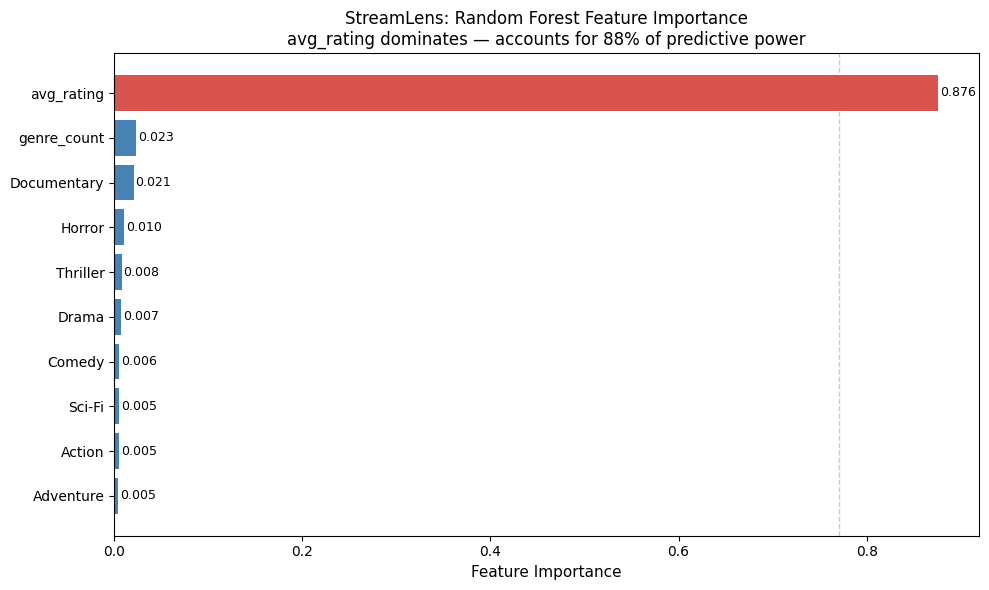

In [39]:
# --- Step 12: Feature Importance Visualization ---

top10 = feature_importance.head(10)

# Highlight avg_rating in a different color
colors = ['#d9534f' if feat == 'avg_rating' else 'steelblue' 
          for feat in top10.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])

# Add value labels
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center', ha='left', fontsize=9)

ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('StreamLens: Random Forest Feature Importance\n'
             'avg_rating dominates — accounts for 88% of predictive power', fontsize=12)

# Add annotation explaining the dominance
ax.axvline(0.771, color='#d9534f', linewidth=1, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/figures/phase3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
print(film_df.head(2))

   movieId  avg_rating  rating_count  \
0        1    3.893508         76813   
1        2    3.278179         30209   

                                        genres  rating_pct  exposure_pct  \
0  Adventure|Animation|Children|Comedy|Fantasy    0.907219      0.999857   
1                   Adventure|Children|Fantasy    0.608397      0.998019   

   bias_score  is_underserved  genre_count  Action  ...  Fantasy  Film-Noir  \
0   -0.092638               0            5       0  ...        1          0   
1   -0.389622               0            3       0  ...        1          0   

   Horror  Musical  Mystery  Romance  Sci-Fi  Thriller  War  Western  
0       0        0        0        0       0         0    0        0  
1       0        0        0        0       0         0    0        0  

[2 rows x 27 columns]


In [43]:
# Export underserved film list for Dashboard use
# Merge title from movies dataframe so Dashboard can display film names
underserved_export = pd.merge(
    film_df[['movieId', 'avg_rating', 'rating_count', 'bias_score', 'is_underserved']],
    movies[['movieId', 'title']],
    on='movieId',
    how='inner'
)

# Reorder columns so title appears first (easier to read)
underserved_export = underserved_export[
    ['title', 'avg_rating', 'rating_count', 'bias_score', 'is_underserved']
].copy()

# Round for cleaner display
underserved_export['avg_rating'] = underserved_export['avg_rating'].round(2)
underserved_export['bias_score'] = underserved_export['bias_score'].round(2)

# Apply minimum rating_count threshold (>=30) for statistical reliability
# avg_rating requires at least 30 samples to be statistically meaningful (CLT)
underserved_export = underserved_export[underserved_export['rating_count'] >= 30].copy()

underserved_export.to_csv('../data/processed/film_underserved.csv', index=False)


print(f"Exported {len(underserved_export)} films")
# underserved_export['is_underserved'].sum() 因為是 boolean 所以 .sum() 等於 is_underserved 電影總數、至於 f"Underserved (is_underserved=1): 只是 f-string 用法
print(f"Exported {len(underserved_export)} films (rating_count >= 30)")
print(f"Underserved (is_underserved=1): {underserved_export['is_underserved'].sum()}")
print(underserved_export.head())


Exported 19394 films
Exported 19394 films (rating_count >= 30)
Underserved (is_underserved=1): 1662
                                title  avg_rating  rating_count  bias_score  \
0                    Toy Story (1995)        3.89         76813       -0.09   
1                      Jumanji (1995)        3.28         30209       -0.39   
2             Grumpier Old Men (1995)        3.17         15820       -0.45   
3            Waiting to Exhale (1995)        2.87          3028       -0.62   
4  Father of the Bride Part II (1995)        3.08         15801       -0.50   

   is_underserved  
0               0  
1               0  
2               0  
3               0  
4               0  


In [44]:
# Check the distribution of underserved films with ratings >= 30
underserved_only = underserved_export[underserved_export['is_underserved'] == 1]

print("=== avg_rating distribution (underserved films) ===")
print(underserved_only['avg_rating'].describe())

print("\n=== rating_count distribution (underserved films) ===")
print(underserved_only['rating_count'].describe())

=== avg_rating distribution (underserved films) ===
count    1662.000000
mean        3.774940
std         0.158118
min         3.510000
25%         3.650000
50%         3.760000
75%         3.870000
max         4.450000
Name: avg_rating, dtype: float64

=== rating_count distribution (underserved films) ===
count    1662.000000
mean      143.664260
std       263.021192
min        30.000000
25%        39.000000
50%        58.500000
75%       119.000000
max      3015.000000
Name: rating_count, dtype: float64
